# Smart Feature Ablation Study (Chronos-2)

This notebook implements a **Smart Feature Selection** strategy to identify the most predictive features for stock volatility.

**Process per Stock:**
1.  **Baseline**: Evaluate model performance with **NO** covariates.
2.  **Screening**: Test every available feature **individually**. 
3.  **Ranking**: Rank features by performance improvement.
4.  **Optimization**: Test combinations (Top-K) to find the sweet spot.
5.  **Visualization**: Generate forecast plots for the **BEST** model found.

**Key Features:**
- **GPU Acceleration**: Uses `cuda` if available.
- **Dynamic Features**: Automatically detects ALL numeric features.
- **Visual Verification**: Plots forecasts with confidence intervals for every stock.

In [1]:

import transformers
try:
    from transformers.models.t5.modeling_t5 import T5ForConditionalGeneration
except ImportError:
    pass

# Patch chronos.chronos2 to have T5ForConditionalGeneration
import chronos.chronos2
try:
    chronos.chronos2.T5ForConditionalGeneration = T5ForConditionalGeneration
except NameError:
    from transformers import T5ForConditionalGeneration
    chronos.chronos2.T5ForConditionalGeneration = T5ForConditionalGeneration

print("Applied T5ForConditionalGeneration patch.")


# Core Imports
import os
import glob
import time
import pandas as pd
import numpy as np
import torch
from chronos import Chronos2Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


c:\Users\lirim\Desktop\SAI\_stonksai\stonksai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Applied T5ForConditionalGeneration patch.
PyTorch version: 2.5.1+cu121
CUDA available: True


In [10]:
# Configuration
DATA_DIR = "../processed_data"
RESULTS_FILE = "smart_ablation_results.csv"
MODEL_NAME = "amazon/chronos-2" 
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TARGET_COL = "ctc_vol"
DATE_COL = "timestamp"
ID_COL = "id"
DEFAULT_ID = "series_1"

# Training parameters
SPLIT_START_DATE = "2020-01-01"
TRAIN_FRACTION = 0.80
PREDICTION_LENGTH = 1 # Next day prediction
FREQ = "B" # Business days

print(f"Using device: {DEVICE}")

Using device: cuda


In [11]:
# Helper Functions

def get_all_features(df, exclude_cols):
    """Dynamically identify all numeric feature columns.
    CRITICAL: Filters out concurrent features to prevent Data Leakage.
    Only allows features with '_lag_' or '_mean' (which are shifted).
    """
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    valid_features = []
    for c in numeric_cols:
        if c in exclude_cols: continue
        
        # Strict filtering for valid forecasting features
        # 1. Explicit lags
        if "_lag_" in c:
            valid_features.append(c)
        # 2. Rolling means (verified to be shifted in generation)
        elif "_mean" in c:
            valid_features.append(c)
            
    return valid_features

def load_and_prep_data(filepath):
    """Load CSV, reindex to business days, and handle missing values."""
    try:
        df = pd.read_csv(filepath)
        df[DATE_COL] = pd.to_datetime(df[DATE_COL])
        df = df.sort_values(DATE_COL).reset_index(drop=True)
        
        # Add ID column if missing
        if ID_COL not in df.columns:
            df[ID_COL] = DEFAULT_ID
            
        # Business day reindexing
        pieces = []
        for sid, g in df.groupby(ID_COL):
            g = g.sort_values(DATE_COL).drop_duplicates(subset=[DATE_COL])
            g = g.set_index(DATE_COL)
            
            # Create full business day range
            start_date = g.index.min()
            end_date = g.index.max()
            bdays_idx = pd.date_range(start=start_date, end=end_date, freq=FREQ)
            
            # Reindex and forward fill
            g = g.reindex(bdays_idx)
            g = g.ffill() # Forward fill missing values from reindexing
            
            g[ID_COL] = sid
            g.index.name = DATE_COL
            pieces.append(g.reset_index())
            
        df_processed = pd.concat(pieces, ignore_index=True)
        
        # Filter for study period
        df_processed = df_processed[df_processed[DATE_COL] >= pd.Timestamp(SPLIT_START_DATE)]
        
        return df_processed.dropna() 
        
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None

def calculate_metrics(y_true, y_pred):
    """Calculate deterministic metrics."""
    metrics = {}
    metrics['mae'] = mean_absolute_error(y_true, y_pred)
    metrics['mse'] = mean_squared_error(y_true, y_pred)
    metrics['rmse'] = np.sqrt(metrics['mse'])
    metrics['r2'] = r2_score(y_true, y_pred)
    return metrics

In [12]:
# Initialize Model
pipeline = Chronos2Pipeline.from_pretrained(
    MODEL_NAME,
    device_map=DEVICE,
    torch_dtype=torch.bfloat16,
)
print("Model loaded successfully.")

Model loaded successfully.


Found 18 stock files.

Processing ABB_ABBNY...
Found 56 potential features.
Running Baseline (No Features)...
  Baseline MAE: 0.005115
Screening 56 features individually...
Testing combination: TOP_1 (1 features)...
  TOP_1 MAE: 0.001210
Testing combination: TOP_2 (2 features)...
  TOP_2 MAE: 0.001151
Testing combination: TOP_3 (3 features)...
  TOP_3 MAE: 0.001110
Testing combination: TOP_4 (4 features)...
  TOP_4 MAE: 0.001053
Testing combination: TOP_5 (5 features)...
  TOP_5 MAE: 0.001075
Testing combination: TOP_6 (6 features)...
  TOP_6 MAE: 0.001091
Testing combination: TOP_7 (7 features)...
  TOP_7 MAE: 0.001059
Testing combination: TOP_8 (8 features)...
  TOP_8 MAE: 0.001082
Testing combination: TOP_9 (9 features)...
  TOP_9 MAE: 0.001089
Testing combination: TOP_10 (10 features)...
  TOP_10 MAE: 0.001080
Testing combination: TOP_11 (11 features)...
  TOP_11 MAE: 0.001079
Testing combination: TOP_12 (12 features)...
  TOP_12 MAE: 0.001089
Testing combination: TOP_13 (13 featur

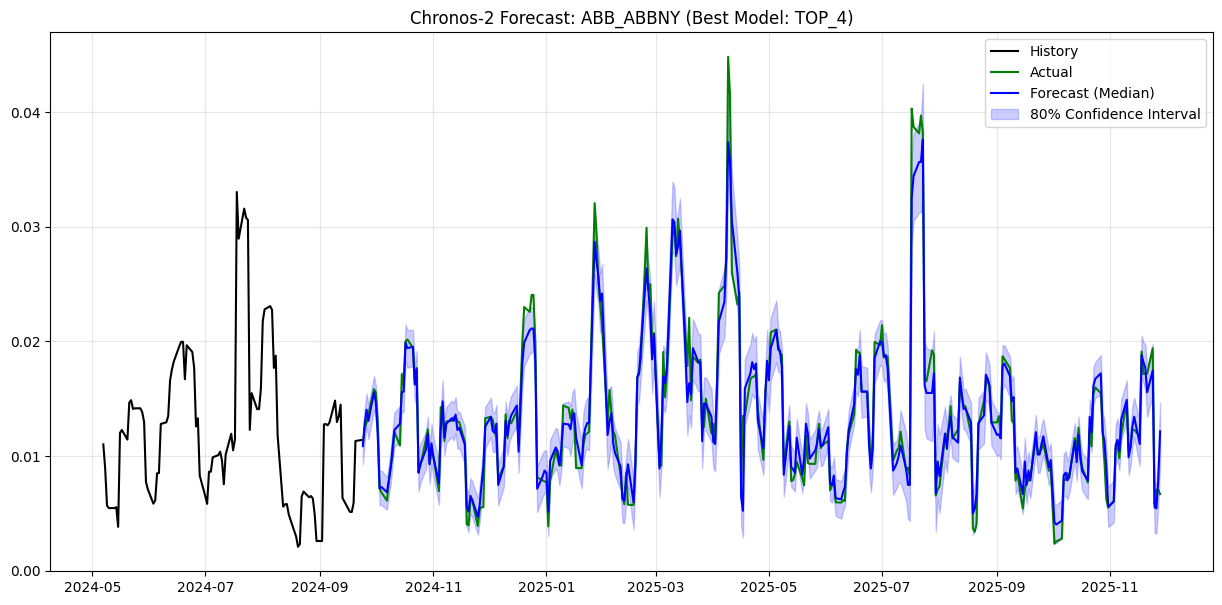

Saved results for ABB_ABBNY

Processing Alcon_0A0D.LON...
Found 56 potential features.
Running Baseline (No Features)...
  Baseline MAE: 0.006569
Screening 56 features individually...
Testing combination: TOP_1 (1 features)...
  TOP_1 MAE: 0.001821
Testing combination: TOP_2 (2 features)...
  TOP_2 MAE: 0.001830
Testing combination: TOP_3 (3 features)...
  TOP_3 MAE: 0.002006
Testing combination: TOP_4 (4 features)...
  TOP_4 MAE: 0.001696
Testing combination: TOP_5 (5 features)...
  TOP_5 MAE: 0.001659
Testing combination: TOP_6 (6 features)...
  TOP_6 MAE: 0.001670
Testing combination: TOP_7 (7 features)...
  TOP_7 MAE: 0.001753
Testing combination: TOP_8 (8 features)...
  TOP_8 MAE: 0.001821
Testing combination: TOP_9 (9 features)...
  TOP_9 MAE: 0.001753
Testing combination: TOP_10 (10 features)...
  TOP_10 MAE: 0.001632
Testing combination: TOP_11 (11 features)...
  TOP_11 MAE: 0.001623
Testing combination: TOP_12 (12 features)...
  TOP_12 MAE: 0.001637
Testing combination: TOP_13

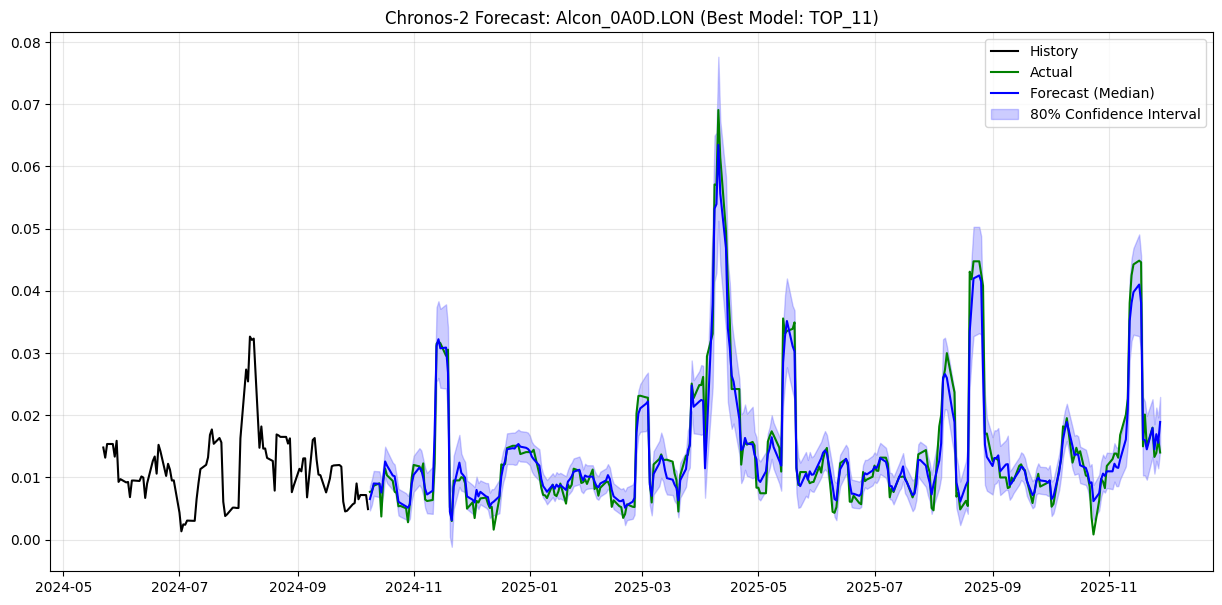

Saved results for Alcon_0A0D.LON

Processing Amrize_AMRZ...
Found 44 potential features.
Running Baseline (No Features)...
  Baseline MAE: 0.006823
Screening 44 features individually...
Testing combination: TOP_1 (1 features)...
  TOP_1 MAE: 0.002311
Testing combination: TOP_2 (2 features)...
  TOP_2 MAE: 0.002533
Testing combination: TOP_3 (3 features)...
  TOP_3 MAE: 0.002613
Testing combination: TOP_4 (4 features)...
  TOP_4 MAE: 0.003156
Testing combination: TOP_5 (5 features)...
  TOP_5 MAE: 0.003043
Testing combination: TOP_6 (6 features)...
  TOP_6 MAE: 0.002512
Testing combination: TOP_7 (7 features)...
  TOP_7 MAE: 0.002526
Testing combination: TOP_8 (8 features)...
  TOP_8 MAE: 0.002484
Testing combination: TOP_9 (9 features)...
  TOP_9 MAE: 0.002468
Testing combination: TOP_10 (10 features)...
  TOP_10 MAE: 0.002509
Testing combination: TOP_11 (11 features)...
  TOP_11 MAE: 0.002503
Testing combination: TOP_12 (12 features)...
  TOP_12 MAE: 0.002660
Testing combination: TOP_

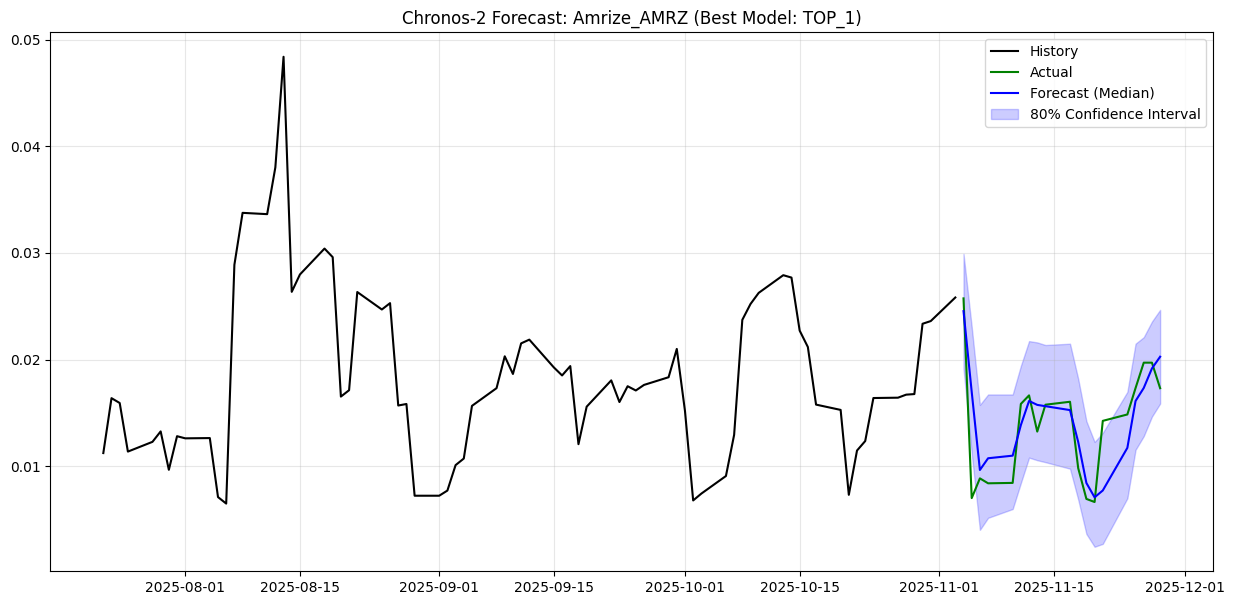

Saved results for Amrize_AMRZ

Processing Geberit_0QQ2.LON...
Found 56 potential features.
Running Baseline (No Features)...
  Baseline MAE: 0.005092
Screening 56 features individually...
Testing combination: TOP_1 (1 features)...
  TOP_1 MAE: 0.001024
Testing combination: TOP_2 (2 features)...
  TOP_2 MAE: 0.001030
Testing combination: TOP_3 (3 features)...
  TOP_3 MAE: 0.001000
Testing combination: TOP_4 (4 features)...
  TOP_4 MAE: 0.000887
Testing combination: TOP_5 (5 features)...
  TOP_5 MAE: 0.000909
Testing combination: TOP_6 (6 features)...
  TOP_6 MAE: 0.000897
Testing combination: TOP_7 (7 features)...
  TOP_7 MAE: 0.000868
Testing combination: TOP_8 (8 features)...
  TOP_8 MAE: 0.000852
Testing combination: TOP_9 (9 features)...
  TOP_9 MAE: 0.000892
Testing combination: TOP_10 (10 features)...
  TOP_10 MAE: 0.000898
Testing combination: TOP_11 (11 features)...
  TOP_11 MAE: 0.000918
Testing combination: TOP_12 (12 features)...
  TOP_12 MAE: 0.000957
Testing combination: TO

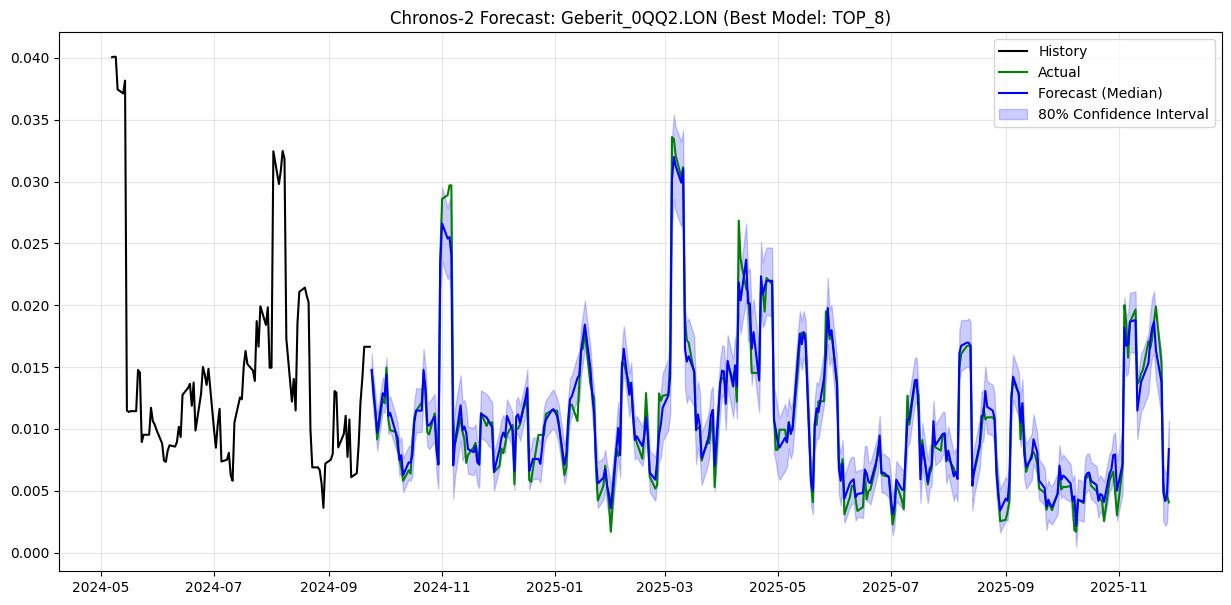

Saved results for Geberit_0QQ2.LON

Processing Givaudan_0QPS.LON...
Found 56 potential features.
Running Baseline (No Features)...
  Baseline MAE: 0.004243
Screening 56 features individually...
Testing combination: TOP_1 (1 features)...
  TOP_1 MAE: 0.001211
Testing combination: TOP_2 (2 features)...
  TOP_2 MAE: 0.001212
Testing combination: TOP_3 (3 features)...
  TOP_3 MAE: 0.001184
Testing combination: TOP_4 (4 features)...
  TOP_4 MAE: 0.001027
Testing combination: TOP_5 (5 features)...
  TOP_5 MAE: 0.000999
Testing combination: TOP_6 (6 features)...
  TOP_6 MAE: 0.001009
Testing combination: TOP_7 (7 features)...
  TOP_7 MAE: 0.001002
Testing combination: TOP_8 (8 features)...
  TOP_8 MAE: 0.000991
Testing combination: TOP_9 (9 features)...
  TOP_9 MAE: 0.001002
Testing combination: TOP_10 (10 features)...
  TOP_10 MAE: 0.000996
Testing combination: TOP_11 (11 features)...
  TOP_11 MAE: 0.001013
Testing combination: TOP_12 (12 features)...
  TOP_12 MAE: 0.001017
Testing combinati

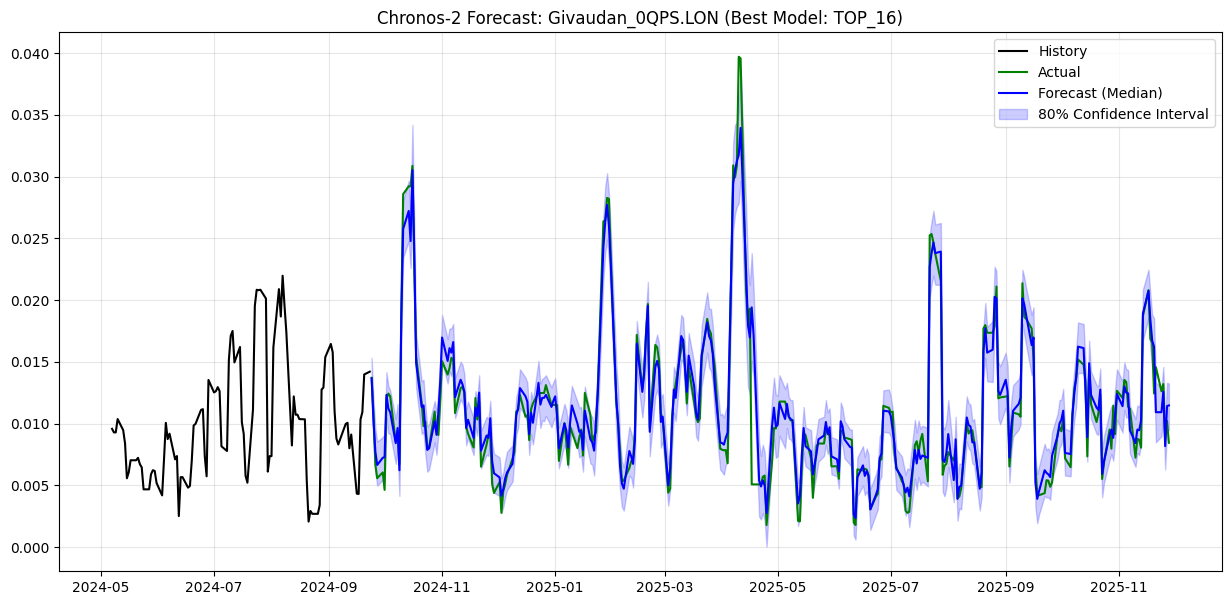

Saved results for Givaudan_0QPS.LON

Processing Holcim_0QKY.LON...
Found 56 potential features.
Running Baseline (No Features)...
  Baseline MAE: 0.016195
Screening 56 features individually...
Testing combination: TOP_1 (1 features)...
  TOP_1 MAE: 0.005470
Testing combination: TOP_2 (2 features)...
  TOP_2 MAE: 0.006060
Testing combination: TOP_3 (3 features)...
  TOP_3 MAE: 0.006055
Testing combination: TOP_4 (4 features)...
  TOP_4 MAE: 0.005782
Testing combination: TOP_5 (5 features)...
  TOP_5 MAE: 0.006254
Testing combination: TOP_6 (6 features)...
  TOP_6 MAE: 0.006327
Testing combination: TOP_7 (7 features)...
  TOP_7 MAE: 0.006635
Testing combination: TOP_8 (8 features)...
  TOP_8 MAE: 0.006980
Testing combination: TOP_9 (9 features)...
  TOP_9 MAE: 0.007274
Testing combination: TOP_10 (10 features)...
  TOP_10 MAE: 0.007471
Testing combination: TOP_11 (11 features)...
  TOP_11 MAE: 0.007675
Testing combination: TOP_12 (12 features)...
  TOP_12 MAE: 0.007913
Testing combinatio

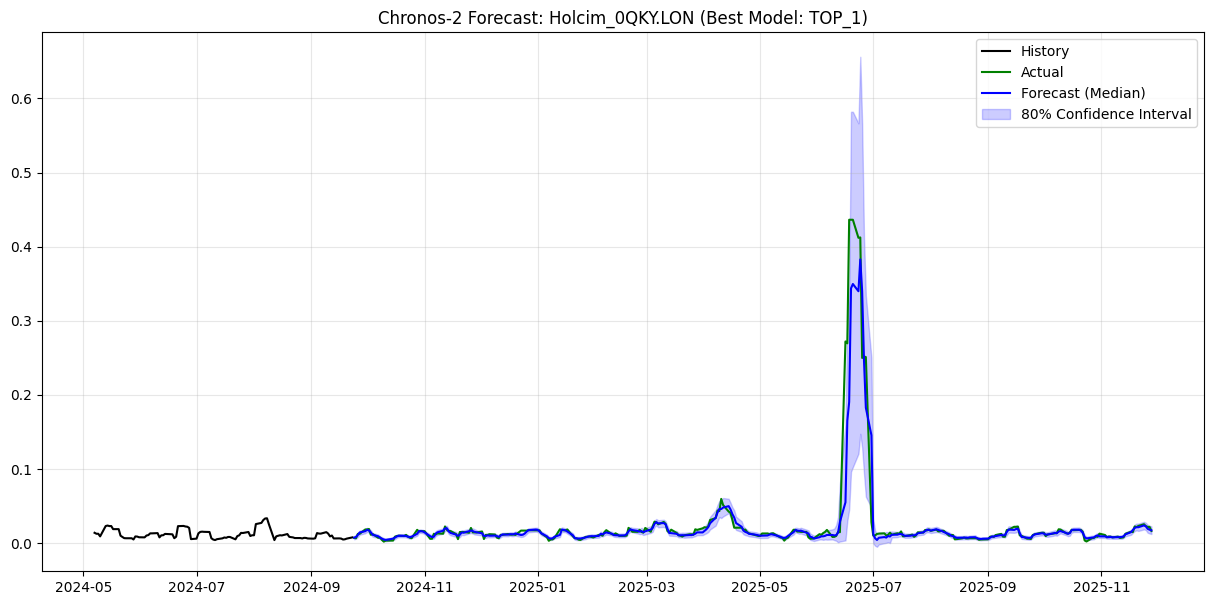

Saved results for Holcim_0QKY.LON

Processing Kuehne_Nagel_0QMW.LON...
Found 56 potential features.
Running Baseline (No Features)...
  Baseline MAE: 0.006342
Screening 56 features individually...
Testing combination: TOP_1 (1 features)...
  TOP_1 MAE: 0.001706
Testing combination: TOP_2 (2 features)...
  TOP_2 MAE: 0.001934
Testing combination: TOP_3 (3 features)...
  TOP_3 MAE: 0.002041
Testing combination: TOP_4 (4 features)...
  TOP_4 MAE: 0.001499
Testing combination: TOP_5 (5 features)...
  TOP_5 MAE: 0.001466
Testing combination: TOP_6 (6 features)...
  TOP_6 MAE: 0.001514
Testing combination: TOP_7 (7 features)...
  TOP_7 MAE: 0.001594
Testing combination: TOP_8 (8 features)...
  TOP_8 MAE: 0.001663
Testing combination: TOP_9 (9 features)...
  TOP_9 MAE: 0.001720
Testing combination: TOP_10 (10 features)...
  TOP_10 MAE: 0.001653
Testing combination: TOP_11 (11 features)...
  TOP_11 MAE: 0.001674
Testing combination: TOP_12 (12 features)...
  TOP_12 MAE: 0.001699
Testing combin

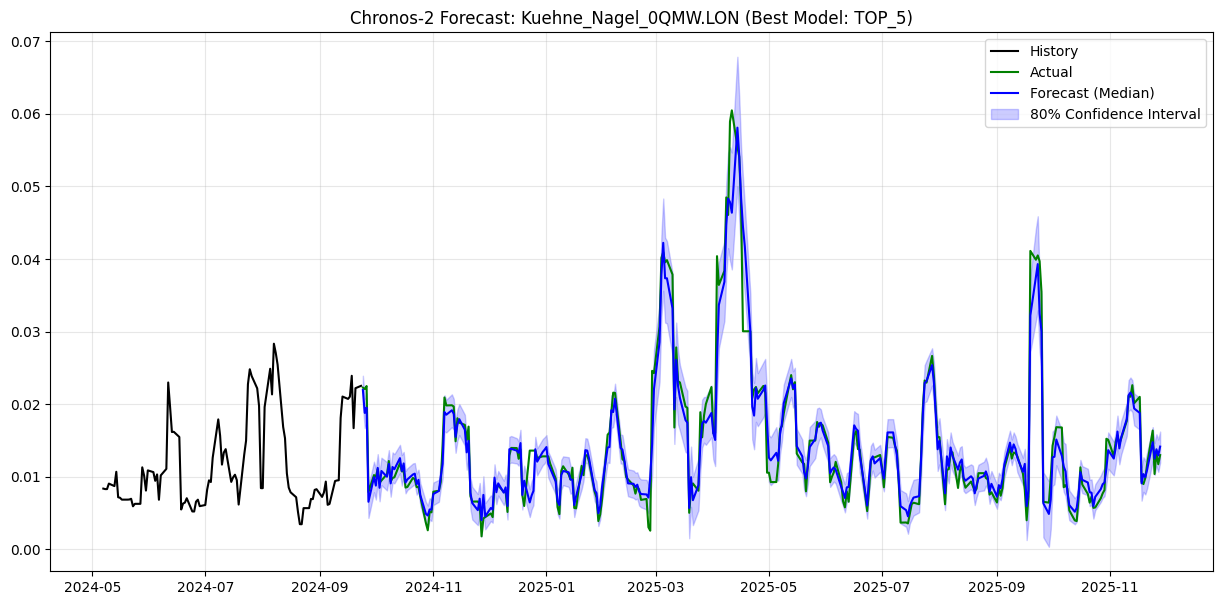

Saved results for Kuehne_Nagel_0QMW.LON

Processing Logitech_0QK6.LON...
Found 56 potential features.
Running Baseline (No Features)...
  Baseline MAE: 0.009101
Screening 56 features individually...
Testing combination: TOP_1 (1 features)...
  TOP_1 MAE: 0.002004
Testing combination: TOP_2 (2 features)...
  TOP_2 MAE: 0.001968
Testing combination: TOP_3 (3 features)...
  TOP_3 MAE: 0.002090
Testing combination: TOP_4 (4 features)...
  TOP_4 MAE: 0.001628
Testing combination: TOP_5 (5 features)...
  TOP_5 MAE: 0.001653
Testing combination: TOP_6 (6 features)...
  TOP_6 MAE: 0.001664
Testing combination: TOP_7 (7 features)...
  TOP_7 MAE: 0.001674
Testing combination: TOP_8 (8 features)...
  TOP_8 MAE: 0.001752
Testing combination: TOP_9 (9 features)...
  TOP_9 MAE: 0.001790
Testing combination: TOP_10 (10 features)...
  TOP_10 MAE: 0.001785
Testing combination: TOP_11 (11 features)...
  TOP_11 MAE: 0.001818
Testing combination: TOP_12 (12 features)...
  TOP_12 MAE: 0.001822
Testing comb

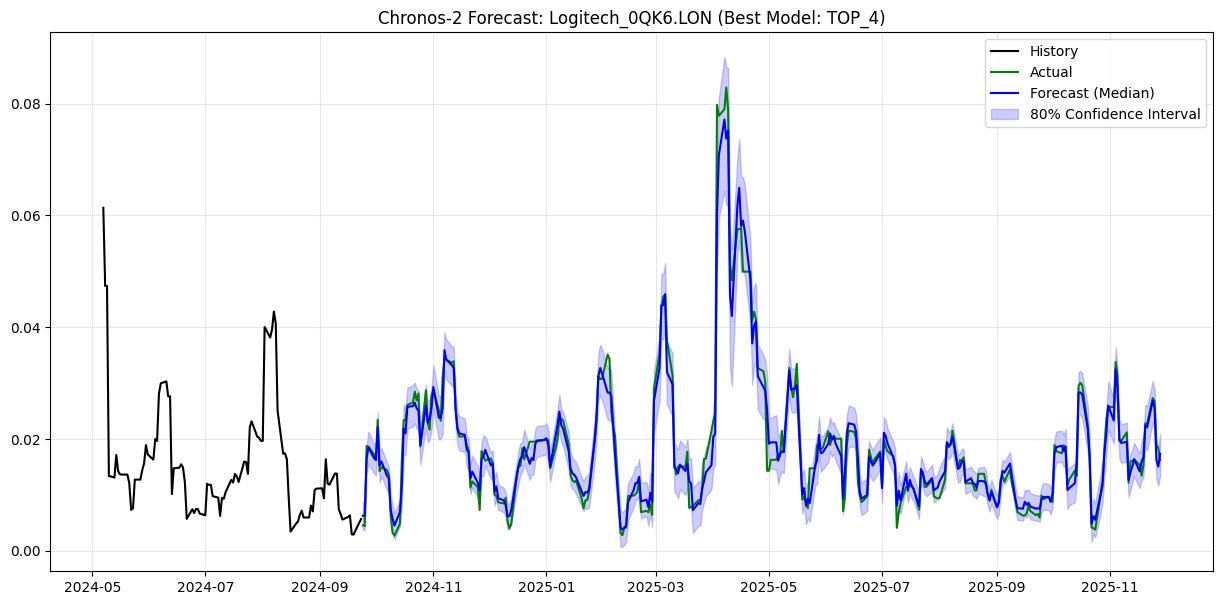

Saved results for Logitech_0QK6.LON

Processing Lonza_0QNO.LON...
Found 56 potential features.
Running Baseline (No Features)...
  Baseline MAE: 0.015199
Screening 56 features individually...
Testing combination: TOP_1 (1 features)...
  TOP_1 MAE: 0.007893
Testing combination: TOP_2 (2 features)...
  TOP_2 MAE: 0.007825
Testing combination: TOP_3 (3 features)...
  TOP_3 MAE: 0.007759
Testing combination: TOP_4 (4 features)...
  TOP_4 MAE: 0.007452
Testing combination: TOP_5 (5 features)...
  TOP_5 MAE: 0.007709
Testing combination: TOP_6 (6 features)...
  TOP_6 MAE: 0.007584
Testing combination: TOP_7 (7 features)...
  TOP_7 MAE: 0.007622
Testing combination: TOP_8 (8 features)...
  TOP_8 MAE: 0.007509
Testing combination: TOP_9 (9 features)...
  TOP_9 MAE: 0.007586
Testing combination: TOP_10 (10 features)...
  TOP_10 MAE: 0.007573
Testing combination: TOP_11 (11 features)...
  TOP_11 MAE: 0.007534
Testing combination: TOP_12 (12 features)...
  TOP_12 MAE: 0.007550
Testing combination

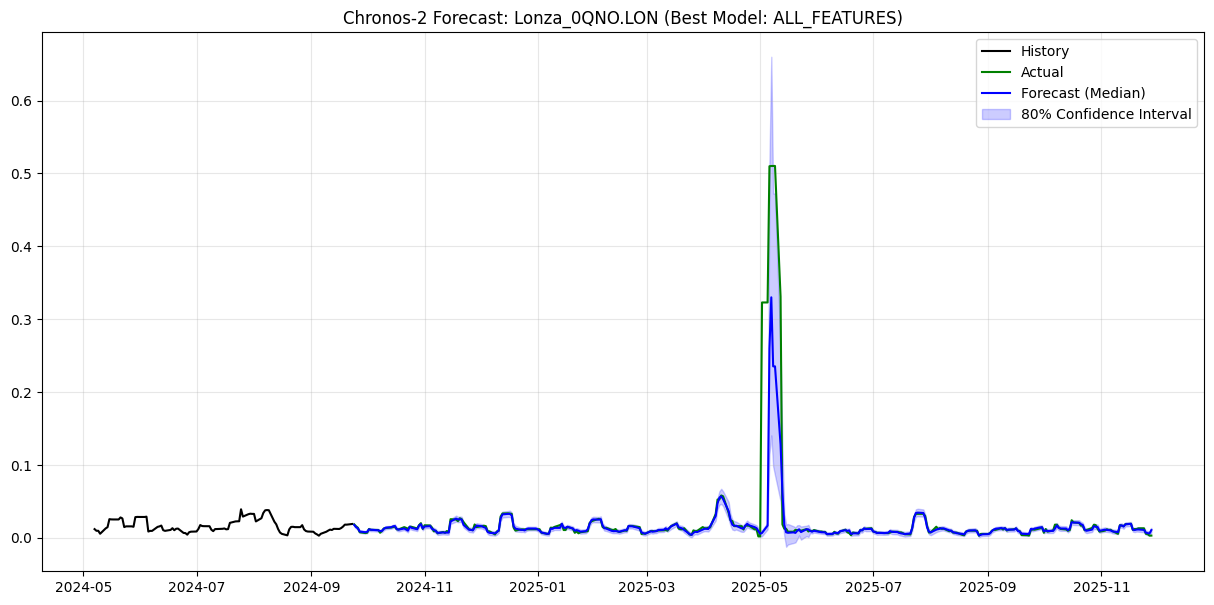

Saved results for Lonza_0QNO.LON

Processing Nestle_NSRGY...
Found 56 potential features.
Running Baseline (No Features)...
  Baseline MAE: 0.005281
Screening 56 features individually...
Testing combination: TOP_1 (1 features)...
  TOP_1 MAE: 0.001407
Testing combination: TOP_2 (2 features)...
  TOP_2 MAE: 0.001420
Testing combination: TOP_3 (3 features)...
  TOP_3 MAE: 0.001389
Testing combination: TOP_4 (4 features)...
  TOP_4 MAE: 0.001050
Testing combination: TOP_5 (5 features)...
  TOP_5 MAE: 0.001052
Testing combination: TOP_6 (6 features)...
  TOP_6 MAE: 0.001064
Testing combination: TOP_7 (7 features)...
  TOP_7 MAE: 0.001105
Testing combination: TOP_8 (8 features)...
  TOP_8 MAE: 0.001111
Testing combination: TOP_9 (9 features)...
  TOP_9 MAE: 0.001131
Testing combination: TOP_10 (10 features)...
  TOP_10 MAE: 0.001137
Testing combination: TOP_11 (11 features)...
  TOP_11 MAE: 0.001167
Testing combination: TOP_12 (12 features)...
  TOP_12 MAE: 0.001206
Testing combination: TOP

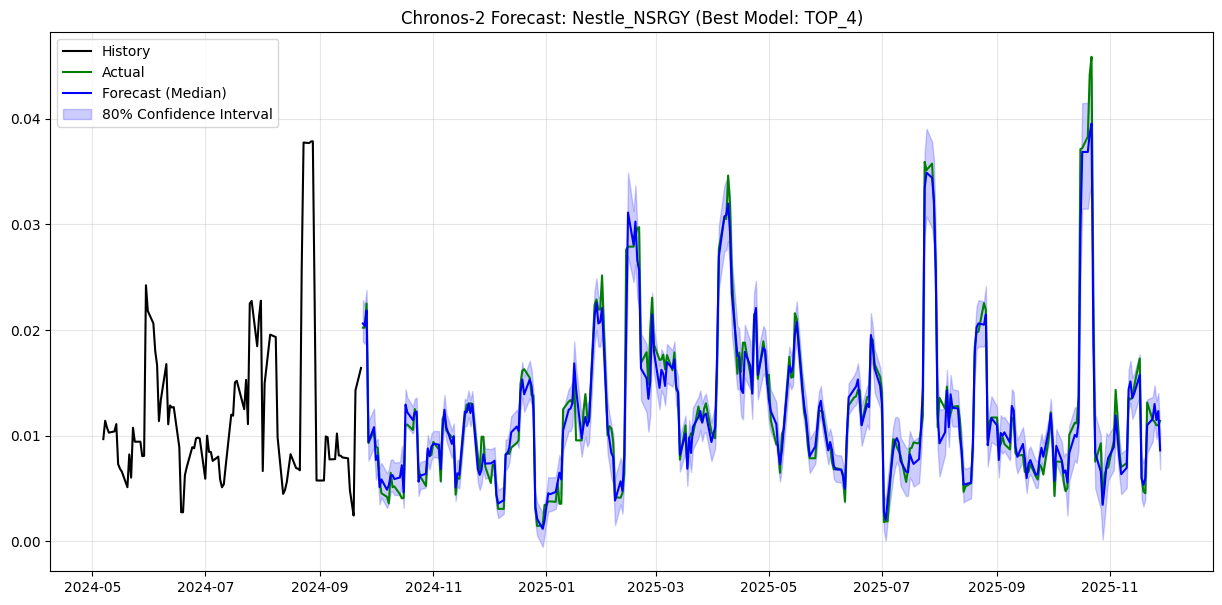

Saved results for Nestle_NSRGY

Processing Novartis_0QLR.LON...
Found 56 potential features.
Running Baseline (No Features)...
  Baseline MAE: 0.004866
Screening 56 features individually...
Testing combination: TOP_1 (1 features)...
  TOP_1 MAE: 0.001133
Testing combination: TOP_2 (2 features)...
  TOP_2 MAE: 0.001272
Testing combination: TOP_3 (3 features)...
  TOP_3 MAE: 0.001325
Testing combination: TOP_4 (4 features)...
  TOP_4 MAE: 0.000940
Testing combination: TOP_5 (5 features)...
  TOP_5 MAE: 0.000933
Testing combination: TOP_6 (6 features)...
  TOP_6 MAE: 0.000931
Testing combination: TOP_7 (7 features)...
  TOP_7 MAE: 0.000917
Testing combination: TOP_8 (8 features)...
  TOP_8 MAE: 0.000927
Testing combination: TOP_9 (9 features)...
  TOP_9 MAE: 0.000939
Testing combination: TOP_10 (10 features)...
  TOP_10 MAE: 0.000979
Testing combination: TOP_11 (11 features)...
  TOP_11 MAE: 0.000982
Testing combination: TOP_12 (12 features)...
  TOP_12 MAE: 0.000990
Testing combination: 

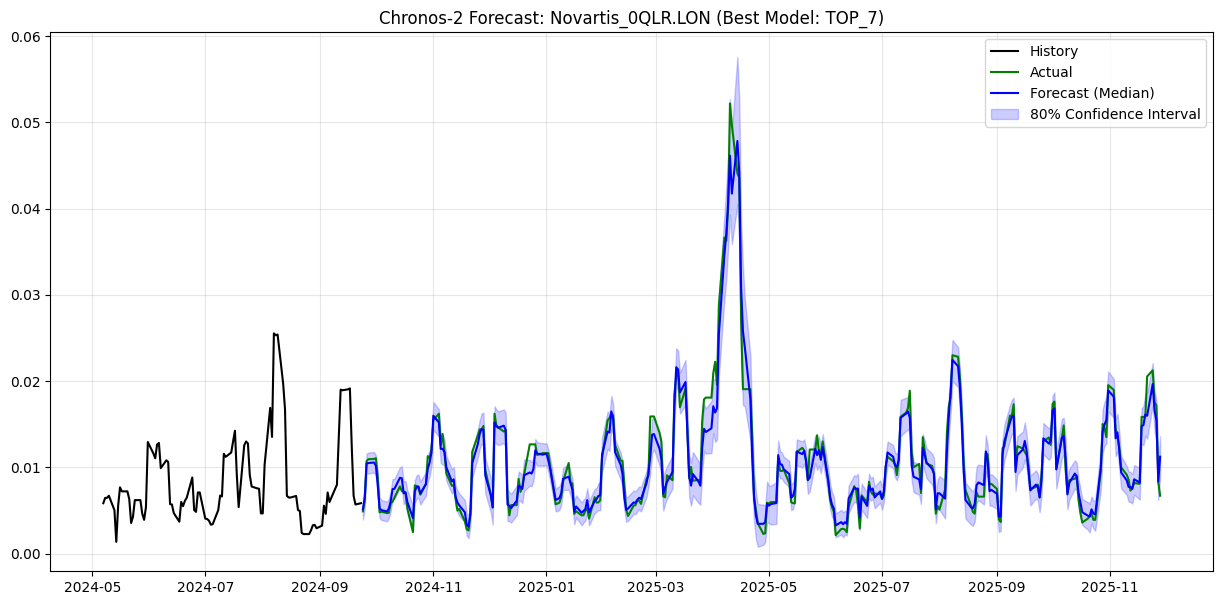

Saved results for Novartis_0QLR.LON

Processing Partners_Group_0QOQ.LON...
Found 56 potential features.
Running Baseline (No Features)...
  Baseline MAE: 0.015477
Screening 56 features individually...
Testing combination: TOP_1 (1 features)...
  TOP_1 MAE: 0.008306
Testing combination: TOP_2 (2 features)...
  TOP_2 MAE: 0.008377
Testing combination: TOP_3 (3 features)...
  TOP_3 MAE: 0.008900
Testing combination: TOP_4 (4 features)...
  TOP_4 MAE: 0.008288
Testing combination: TOP_5 (5 features)...
  TOP_5 MAE: 0.008134
Testing combination: TOP_6 (6 features)...
  TOP_6 MAE: 0.007962
Testing combination: TOP_7 (7 features)...
  TOP_7 MAE: 0.007977
Testing combination: TOP_8 (8 features)...
  TOP_8 MAE: 0.007916
Testing combination: TOP_9 (9 features)...
  TOP_9 MAE: 0.008034
Testing combination: TOP_10 (10 features)...
  TOP_10 MAE: 0.007984
Testing combination: TOP_11 (11 features)...
  TOP_11 MAE: 0.008021
Testing combination: TOP_12 (12 features)...
  TOP_12 MAE: 0.008043
Testing co

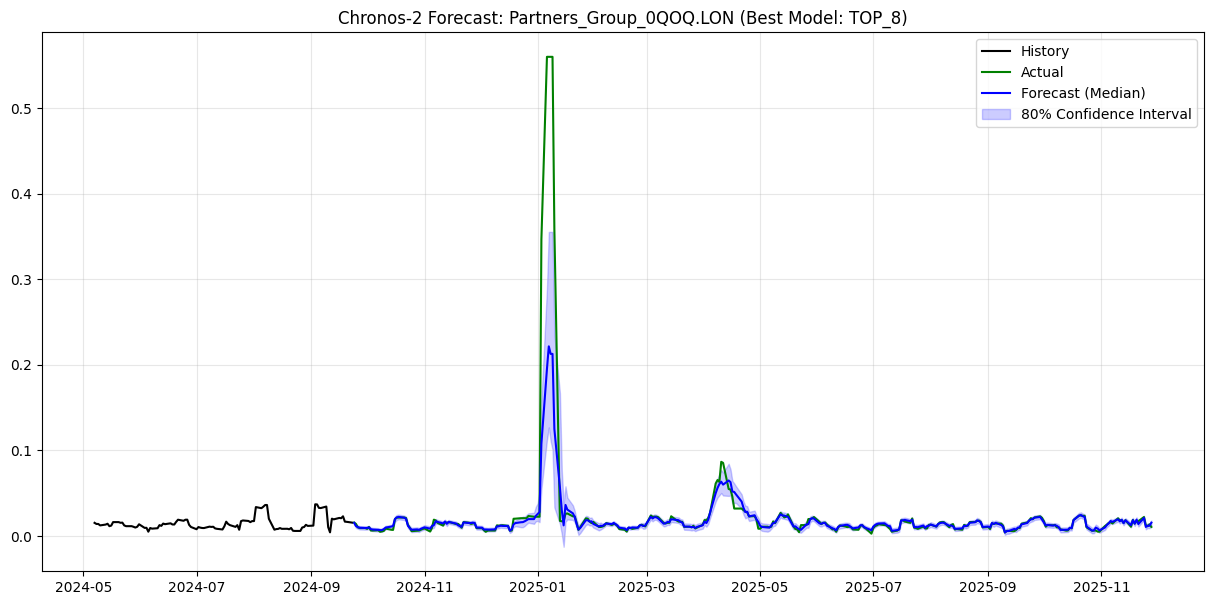

Saved results for Partners_Group_0QOQ.LON

Processing Roche_RHO6.FRK...
Found 56 potential features.
Running Baseline (No Features)...
  Baseline MAE: 0.005792
Screening 56 features individually...
Testing combination: TOP_1 (1 features)...
  TOP_1 MAE: 0.001268
Testing combination: TOP_2 (2 features)...
  TOP_2 MAE: 0.001289
Testing combination: TOP_3 (3 features)...
  TOP_3 MAE: 0.001176
Testing combination: TOP_4 (4 features)...
  TOP_4 MAE: 0.001109
Testing combination: TOP_5 (5 features)...
  TOP_5 MAE: 0.001084
Testing combination: TOP_6 (6 features)...
  TOP_6 MAE: 0.001077
Testing combination: TOP_7 (7 features)...
  TOP_7 MAE: 0.001067
Testing combination: TOP_8 (8 features)...
  TOP_8 MAE: 0.001074
Testing combination: TOP_9 (9 features)...
  TOP_9 MAE: 0.001082
Testing combination: TOP_10 (10 features)...
  TOP_10 MAE: 0.001071
Testing combination: TOP_11 (11 features)...
  TOP_11 MAE: 0.001070
Testing combination: TOP_12 (12 features)...
  TOP_12 MAE: 0.001087
Testing combi

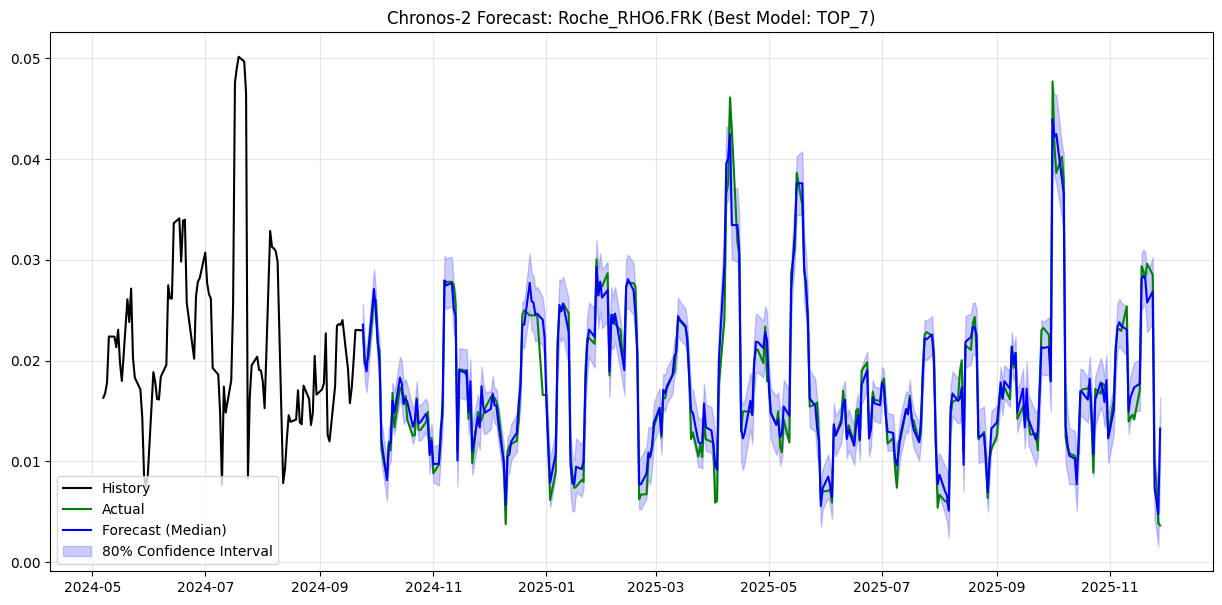

Saved results for Roche_RHO6.FRK

Processing Sika_0Z4C.LON...
Found 56 potential features.
Running Baseline (No Features)...
  Baseline MAE: 0.004598
Screening 56 features individually...
Testing combination: TOP_1 (1 features)...
  TOP_1 MAE: 0.001245
Testing combination: TOP_2 (2 features)...
  TOP_2 MAE: 0.001200
Testing combination: TOP_3 (3 features)...
  TOP_3 MAE: 0.001194
Testing combination: TOP_4 (4 features)...
  TOP_4 MAE: 0.001037
Testing combination: TOP_5 (5 features)...
  TOP_5 MAE: 0.001018
Testing combination: TOP_6 (6 features)...
  TOP_6 MAE: 0.001015
Testing combination: TOP_7 (7 features)...
  TOP_7 MAE: 0.001009
Testing combination: TOP_8 (8 features)...
  TOP_8 MAE: 0.001027
Testing combination: TOP_9 (9 features)...
  TOP_9 MAE: 0.001041
Testing combination: TOP_10 (10 features)...
  TOP_10 MAE: 0.001075
Testing combination: TOP_11 (11 features)...
  TOP_11 MAE: 0.001085
Testing combination: TOP_12 (12 features)...
  TOP_12 MAE: 0.001101
Testing combination: TO

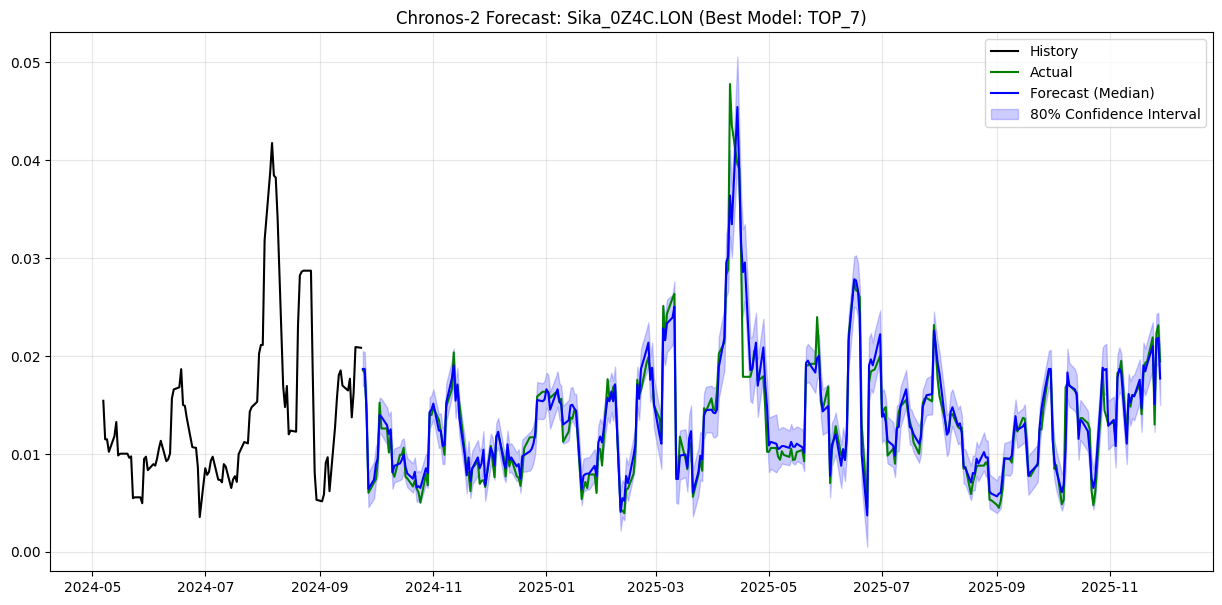

Saved results for Sika_0Z4C.LON

Processing Swisscom_0QKI.LON...
Found 56 potential features.
Running Baseline (No Features)...
  Baseline MAE: 0.003538
Screening 56 features individually...
Testing combination: TOP_1 (1 features)...
  TOP_1 MAE: 0.000841
Testing combination: TOP_2 (2 features)...
  TOP_2 MAE: 0.000835
Testing combination: TOP_3 (3 features)...
  TOP_3 MAE: 0.000810
Testing combination: TOP_4 (4 features)...
  TOP_4 MAE: 0.000777
Testing combination: TOP_5 (5 features)...
  TOP_5 MAE: 0.000773
Testing combination: TOP_6 (6 features)...
  TOP_6 MAE: 0.000754
Testing combination: TOP_7 (7 features)...
  TOP_7 MAE: 0.000761
Testing combination: TOP_8 (8 features)...
  TOP_8 MAE: 0.000742
Testing combination: TOP_9 (9 features)...
  TOP_9 MAE: 0.000723
Testing combination: TOP_10 (10 features)...
  TOP_10 MAE: 0.000718
Testing combination: TOP_11 (11 features)...
  TOP_11 MAE: 0.000734
Testing combination: TOP_12 (12 features)...
  TOP_12 MAE: 0.000751
Testing combination:

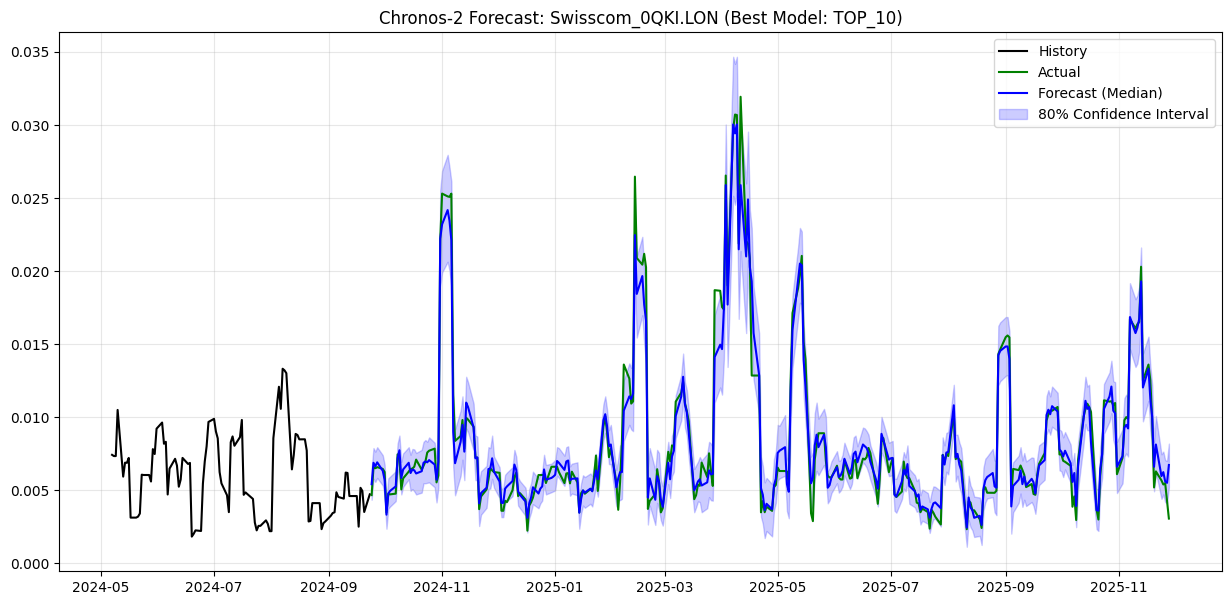

Saved results for Swisscom_0QKI.LON

Processing Swiss_Life_0QMG.LON...
Found 56 potential features.
Running Baseline (No Features)...
  Baseline MAE: 0.004231
Screening 56 features individually...
Testing combination: TOP_1 (1 features)...
  TOP_1 MAE: 0.001017
Testing combination: TOP_2 (2 features)...
  TOP_2 MAE: 0.001146
Testing combination: TOP_3 (3 features)...
  TOP_3 MAE: 0.001294
Testing combination: TOP_4 (4 features)...
  TOP_4 MAE: 0.000998
Testing combination: TOP_5 (5 features)...
  TOP_5 MAE: 0.000975
Testing combination: TOP_6 (6 features)...
  TOP_6 MAE: 0.000972
Testing combination: TOP_7 (7 features)...
  TOP_7 MAE: 0.000974
Testing combination: TOP_8 (8 features)...
  TOP_8 MAE: 0.000975
Testing combination: TOP_9 (9 features)...
  TOP_9 MAE: 0.000989
Testing combination: TOP_10 (10 features)...
  TOP_10 MAE: 0.001029
Testing combination: TOP_11 (11 features)...
  TOP_11 MAE: 0.001042
Testing combination: TOP_12 (12 features)...
  TOP_12 MAE: 0.001060
Testing combin

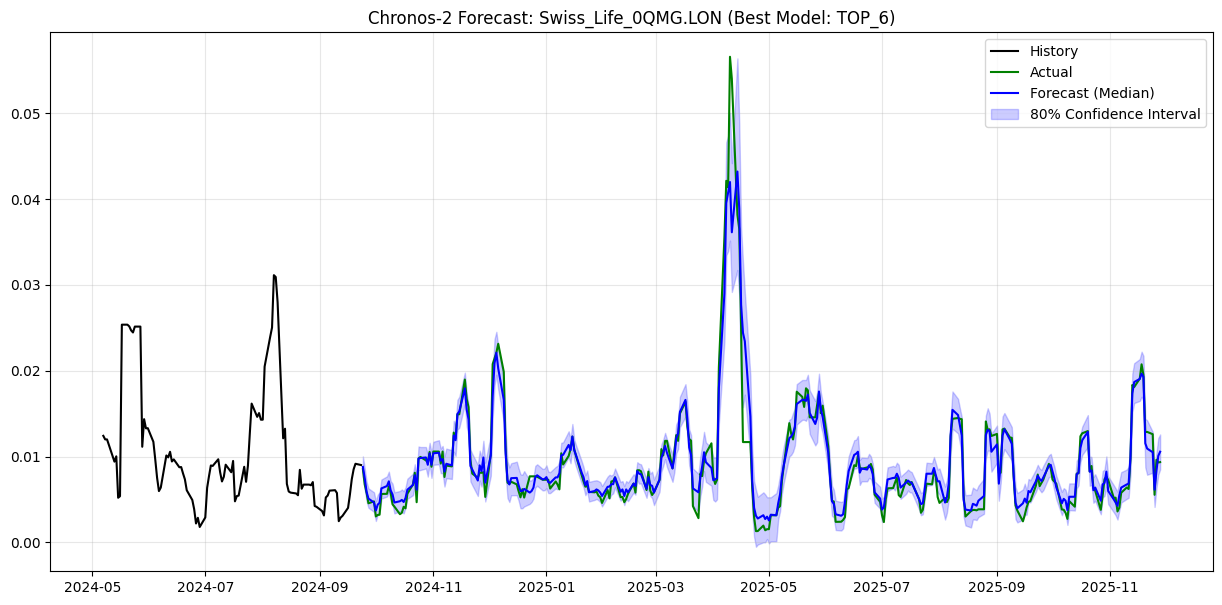

Saved results for Swiss_Life_0QMG.LON

Processing UBS_UBS...
Found 56 potential features.
Running Baseline (No Features)...
  Baseline MAE: 0.005902
Screening 56 features individually...
Testing combination: TOP_1 (1 features)...
  TOP_1 MAE: 0.001600
Testing combination: TOP_2 (2 features)...
  TOP_2 MAE: 0.001596
Testing combination: TOP_3 (3 features)...
  TOP_3 MAE: 0.001609
Testing combination: TOP_4 (4 features)...
  TOP_4 MAE: 0.001347
Testing combination: TOP_5 (5 features)...
  TOP_5 MAE: 0.001344
Testing combination: TOP_6 (6 features)...
  TOP_6 MAE: 0.001338
Testing combination: TOP_7 (7 features)...
  TOP_7 MAE: 0.001340
Testing combination: TOP_8 (8 features)...
  TOP_8 MAE: 0.001264
Testing combination: TOP_9 (9 features)...
  TOP_9 MAE: 0.001306
Testing combination: TOP_10 (10 features)...
  TOP_10 MAE: 0.001316
Testing combination: TOP_11 (11 features)...
  TOP_11 MAE: 0.001293
Testing combination: TOP_12 (12 features)...
  TOP_12 MAE: 0.001302
Testing combination: TOP

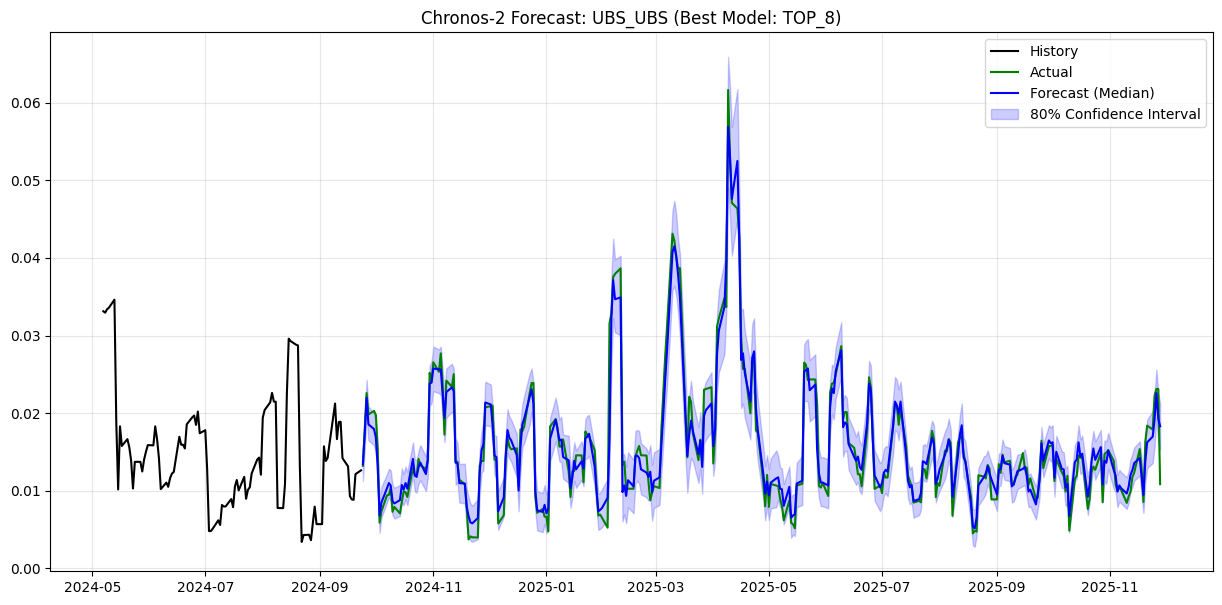

Saved results for UBS_UBS

Processing Zurich_Insurance_0QP2.LON...
Found 56 potential features.
Running Baseline (No Features)...
  Baseline MAE: 0.004045
Screening 56 features individually...
Testing combination: TOP_1 (1 features)...
  TOP_1 MAE: 0.001138
Testing combination: TOP_2 (2 features)...
  TOP_2 MAE: 0.001142
Testing combination: TOP_3 (3 features)...
  TOP_3 MAE: 0.001274
Testing combination: TOP_4 (4 features)...
  TOP_4 MAE: 0.001074
Testing combination: TOP_5 (5 features)...
  TOP_5 MAE: 0.001054
Testing combination: TOP_6 (6 features)...
  TOP_6 MAE: 0.001031
Testing combination: TOP_7 (7 features)...
  TOP_7 MAE: 0.001033
Testing combination: TOP_8 (8 features)...
  TOP_8 MAE: 0.001030
Testing combination: TOP_9 (9 features)...
  TOP_9 MAE: 0.001027
Testing combination: TOP_10 (10 features)...
  TOP_10 MAE: 0.001086
Testing combination: TOP_11 (11 features)...
  TOP_11 MAE: 0.001070
Testing combination: TOP_12 (12 features)...
  TOP_12 MAE: 0.001060
Testing combinatio

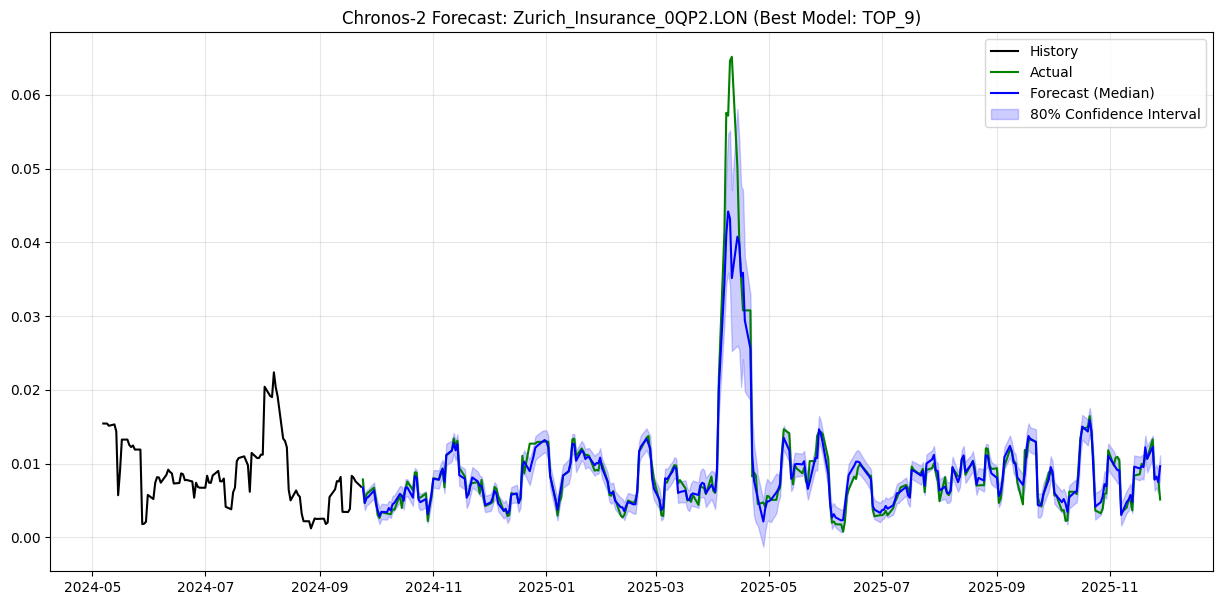

Saved results for Zurich_Insurance_0QP2.LON

Smart Ablation study complete!


In [13]:
# Run Smart Ablation Study

results = []
csv_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))
print(f"Found {len(csv_files)} stock files.")

for filepath in csv_files:
    stock_name = os.path.basename(filepath).replace("data_", "").replace(".csv", "")
    print(f"\n{'='*50}")
    print(f"Processing {stock_name}...")
    print(f"{'='*50}")
    
    # Load data
    df = load_and_prep_data(filepath)
    if df is None or len(df) < 50:
        print(f"Skipping {stock_name} due to insufficient data.")
        continue
        
    # Identify ALL features
    exclude = [TARGET_COL, DATE_COL, ID_COL]
    all_features = get_all_features(df, exclude)
    print(f"Found {len(all_features)} potential features.")
    
    # Train/Test Split
    n_total = len(df)
    n_train = int(np.floor(TRAIN_FRACTION * n_total))
    
    context_df = df.iloc[:n_train].copy()
    future_df = df.iloc[n_train:].copy()
    actuals = future_df[TARGET_COL].values
    
    # ---------------------------------------------------------
    # 1. Baseline (No Features)
    # ---------------------------------------------------------
    print("Running Baseline (No Features)...")
    try:
        start_time = time.time()
        # Context needs target only
        context_input = context_df[[ID_COL, DATE_COL, TARGET_COL]]
        
        forecast = pipeline.predict_df(
            context_input,
            prediction_length=len(future_df),
            quantile_levels=[0.5],
            target=TARGET_COL,
            id_column=ID_COL,
            timestamp_column=DATE_COL
        )
        preds = forecast['0.5'].values
        metrics = calculate_metrics(actuals, preds)
        
        baseline_result = {
            'stock': stock_name,
            'features': 'BASELINE_NONE',
            'n_features': 0,
            'mae': metrics['mae'],
            'mse': metrics['mse'],
            'rmse': metrics['rmse'],
            'r2': metrics['r2'],
            'time': time.time() - start_time
        }
        results.append(baseline_result)
        print(f"  Baseline MAE: {metrics['mae']:.6f}")
        
    except Exception as e:
        print(f"  Error in Baseline: {e}")

    # ---------------------------------------------------------
    # 2. Individual Feature Screening
    # ---------------------------------------------------------
    print(f"Screening {len(all_features)} features individually...")
    feature_performance = []
    
    for i, feat in enumerate(all_features):
        if i % 10 == 0: print(f"  Feature {i}/{len(all_features)}", end="\r")
        
        try:
            start_time = time.time()
            feats = [feat]
            
            context_cols = [ID_COL, DATE_COL, TARGET_COL] + feats
            future_cols = [ID_COL, DATE_COL] + feats
            
            forecast = pipeline.predict_df(
                context_df[context_cols],
                future_df[future_cols],
                prediction_length=len(future_df),
                quantile_levels=[0.5],
                target=TARGET_COL,
                id_column=ID_COL,
                timestamp_column=DATE_COL
            )
            preds = forecast['0.5'].values
            metrics = calculate_metrics(actuals, preds)
            
            res = {
                'stock': stock_name,
                'features': feat,
                'n_features': 1,
                'mae': metrics['mae'],
                'mse': metrics['mse'],
                'rmse': metrics['rmse'],
                'r2': metrics['r2'],
                'time': time.time() - start_time
            }
            results.append(res)
            feature_performance.append((feat, metrics['mae']))
            
        except Exception as e:
            print(f"  Error with feature {feat}: {e}")
            
    # ---------------------------------------------------------
    # 3. Top-K Sweep (Finding the Optimal K)
    # ---------------------------------------------------------
    # Sort features by MAE (ascending -> lower is better)
    feature_performance.sort(key=lambda x: x[1])
    
    # Test a range of K to find the "sweet spot"
    # User requested Top 1 to 20
    k_values = list(range(1, 21))
    
    # Also test ALL features
    combinations_to_test = [(f"TOP_{k}", k) for k in k_values]
    combinations_to_test.append(("ALL_FEATURES", len(all_features)))
    
    best_mae = float('inf')
    best_k_name = "None"
    best_k_val = 0
    
    for name, k in combinations_to_test:
        try:
            if k > len(all_features): k = len(all_features)
            
            # Select features
            if name == "ALL_FEATURES":
                selected_feats = all_features
            else:
                selected_feats = [x[0] for x in feature_performance[:k]]
            
            # Skip if we already tested this exact set (e.g. if len(all) < 20)
            if len(selected_feats) == 0: continue
            
            print(f"Testing combination: {name} ({len(selected_feats)} features)...")
            start_time = time.time()
            
            context_cols = [ID_COL, DATE_COL, TARGET_COL] + selected_feats
            future_cols = [ID_COL, DATE_COL] + selected_feats
            
            forecast = pipeline.predict_df(
                context_df[context_cols],
                future_df[future_cols],
                prediction_length=len(future_df),
                quantile_levels=[0.5],
                target=TARGET_COL,
                id_column=ID_COL,
                timestamp_column=DATE_COL
            )
            preds = forecast['0.5'].values
            metrics = calculate_metrics(actuals, preds)
            
            combo_res = {
                'stock': stock_name,
                'features': f"{name}_COMBINED",
                'n_features': len(selected_feats),
                'mae': metrics['mae'],
                'mse': metrics['mse'],
                'rmse': metrics['rmse'],
                'r2': metrics['r2'],
                'time': time.time() - start_time
            }
            results.append(combo_res)
            print(f"  {name} MAE: {metrics['mae']:.6f}")
            
            # Track best model
            if metrics['mae'] < best_mae:
                best_mae = metrics['mae']
                best_k_name = name
                best_k_val = len(selected_feats)
            
        except Exception as e:
            print(f"  Error with {name}: {e}")

    # ---------------------------------------------------------
    # 4. Visualization (BEST Forecast)
    # ---------------------------------------------------------
    try:
        print(f"Generating forecast plot for {stock_name} using BEST model: {best_k_name} ({best_k_val} features)...")
        
        # Use Best-K features for plotting
        if best_k_name == "ALL_FEATURES":
            plot_feats = all_features
        else:
            # Extract K from name or use best_k_val
            plot_feats = [x[0] for x in feature_performance[:best_k_val]]
        
        context_cols = [ID_COL, DATE_COL, TARGET_COL] + plot_feats
        future_cols = [ID_COL, DATE_COL] + plot_feats
        
        # Generate forecast with quantiles for plotting
        forecast = pipeline.predict_df(
            context_df[context_cols],
            future_df[future_cols],
            prediction_length=len(future_df),
            quantile_levels=[0.1, 0.5, 0.9],
            target=TARGET_COL,
            id_column=ID_COL,
            timestamp_column=DATE_COL
        )
        
        # Plotting
        plt.figure(figsize=(15, 7))
        
        # Plot historical context (last 100 days)
        plt.plot(context_df[DATE_COL].iloc[-100:], context_df[TARGET_COL].iloc[-100:], color="black", label="History")
        
        # Plot Actual Future
        plt.plot(future_df[DATE_COL], future_df[TARGET_COL], color="green", label="Actual")
        
        # Plot Forecast
        plt.plot(forecast[DATE_COL], forecast['0.5'], color="blue", label="Forecast (Median)")
        plt.fill_between(forecast[DATE_COL], forecast['0.1'], forecast['0.9'], color="blue", alpha=0.2, label="80% Confidence Interval")
        
        plt.title(f"Chronos-2 Forecast: {stock_name} (Best Model: {best_k_name})")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show() # Display inline
        
    except Exception as e:
        print(f"Error plotting {stock_name}: {e}")

    # Save intermediate results
    pd.DataFrame(results).to_csv(RESULTS_FILE, index=False)
    print(f"Saved results for {stock_name}")

print("\nSmart Ablation study complete!")